# Project 13: HR Analytics Dashboard
### Why Are Employees Leaving, and Who Is Most Likely to Leave Next?

---

## Business Brief

Employee attrition costs businesses between 50% and 200% of an employee's annual salary when you factor in recruitment, onboarding, lost productivity, and institutional knowledge. Most HR teams track headcount and turnover rate. Very few use data to understand the drivers of attrition or predict who is at risk.

This project builds a complete HR analytics system that answers:

1. What is the overall attrition rate and how does it vary by department and role?
2. What employee characteristics correlate most strongly with attrition?
3. Can we predict which employees are most likely to leave?
4. What does the financial cost of attrition look like by department?
5. Unique finding: an Employee Risk Score that identifies at-risk employees before they resign

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | IBM HR Analytics Employee Attrition Dataset |
| **Direct Link** | https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset |
| **Records** | 1,470 employees with 35 features |
| **Target** | Attrition: Yes / No |

## Tools
`Python` `Pandas` `NumPy` `SQL (sqlite3)` `Scikit-learn` `Plotly` `Matplotlib` `Seaborn`

---

## What Makes This Different

- Uses SQL for all department and role level aggregations
- Calculates the financial cost of attrition per department
- Builds a predictive attrition model and assigns a risk score to every employee
- Introduces an Employee Risk Matrix: risk score vs seniority
- Unique finding: identifies the specific combination of factors that creates the highest attrition risk profile


---
## Section 1: Setup

In [4]:
import sqlite3, warnings, os, glob
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'attrition': '#EF4444',
    'retained':  '#10B981',
    'high_risk': '#EF4444',
    'mid_risk':  '#F59E0B',
    'low_risk':  '#10B981',
    'primary':   '#6366F1',
    'bg':        '#F8FAFC',
    'subtext':   '#64748B',
    'dark':      '#0F172A',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})
print('Setup complete.')
print('Red = Attrition | Green = Retained | Indigo = Model')


Setup complete.
Red = Attrition | Green = Retained | Indigo = Model


---
## Section 2: Load Data

In [5]:
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print('Files found:')
for f in csv_files:
    print(f'  {f}')


Files found:
  /kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [6]:
DATA_PATH = '/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv'

for enc in ['utf-8', 'latin-1', 'ISO-8859-1']:
    try:
        df = pd.read_csv(DATA_PATH, encoding=enc)
        print(f'Loaded with encoding: {enc}')
        break
    except Exception as e:
        print(f'Failed {enc}: {e}')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f'Overall attrition rate: {attrition_rate:.1f}%')
print()
print(df.head(3).T)


Loaded with encoding: utf-8
Shape: 1,470 rows x 35 columns

Overall attrition rate: 16.1%

                                        0                       1  \
Age                                    41                      49   
Attrition                             Yes                      No   
BusinessTravel              Travel_Rarely       Travel_Frequently   
DailyRate                            1102                     279   
Department                          Sales  Research & Development   
DistanceFromHome                        1                       8   
Education                               2                       1   
EducationField              Life Sciences           Life Sciences   
EmployeeCount                           1                       1   
EmployeeNumber                          1                       2   
EnvironmentSatisfaction                 2                       3   
Gender                             Female                    Male   
HourlyRate  

---
## Section 3: Prepare Data

In [7]:
# Standardise column names
df.columns = (
    df.columns.str.strip()
              .str.replace(' ', '_')
)

# Create binary attrition column
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

# Drop columns with zero variance
zero_var = [c for c in df.columns if df[c].nunique() <= 1]
if zero_var:
    df = df.drop(columns=zero_var)
    print(f'Dropped zero-variance columns: {zero_var}')

print(f'Clean shape: {df.shape}')
print()
print('Attrition breakdown:')
counts = df['Attrition'].value_counts()
pcts   = df['Attrition'].value_counts(normalize=True) * 100
for v in counts.index:
    print(f'  {v:<5} {counts[v]:>6,}  ({pcts[v]:.1f}%)')


Dropped zero-variance columns: ['EmployeeCount', 'Over18', 'StandardHours']
Clean shape: (1470, 33)

Attrition breakdown:
  No     1,233  (83.9%)
  Yes      237  (16.1%)


---
## Section 4: SQL HR Analytics Queries

In [8]:
conn = sqlite3.connect(':memory:')
df.to_sql('employees', conn, index=False, if_exists='replace')
print('Loaded into SQLite.')

sql_dept = (
    'SELECT Department,'
    ' COUNT(*) as headcount,'
    ' SUM(Attrition_Binary) as attritions,'
    ' ROUND(CAST(SUM(Attrition_Binary) AS FLOAT)/COUNT(*)*100, 1) as attrition_rate_pct,'
    ' ROUND(AVG(MonthlyIncome), 0) as avg_monthly_income,'
    ' ROUND(AVG(YearsAtCompany), 1) as avg_tenure_yrs,'
    ' ROUND(AVG(JobSatisfaction), 2) as avg_job_satisfaction'
    ' FROM employees'
    ' GROUP BY Department'
    ' ORDER BY attrition_rate_pct DESC'
)
print('=== ATTRITION BY DEPARTMENT ===')
dept_df = pd.read_sql_query(sql_dept, conn)
print(dept_df.to_string(index=False))


Loaded into SQLite.
=== ATTRITION BY DEPARTMENT ===
            Department  headcount  attritions  attrition_rate_pct  avg_monthly_income  avg_tenure_yrs  avg_job_satisfaction
                 Sales        446          92                20.6              6959.0             7.3                  2.75
       Human Resources         63          12                19.0              6655.0             7.2                  2.60
Research & Development        961         133                13.8              6281.0             6.9                  2.73


In [9]:
sql_role = (
    'SELECT JobRole,'
    ' COUNT(*) as headcount,'
    ' SUM(Attrition_Binary) as attritions,'
    ' ROUND(CAST(SUM(Attrition_Binary) AS FLOAT)/COUNT(*)*100, 1) as attrition_rate_pct,'
    ' ROUND(AVG(MonthlyIncome), 0) as avg_monthly_income,'
    ' ROUND(AVG(JobSatisfaction), 2) as avg_satisfaction'
    ' FROM employees'
    ' GROUP BY JobRole'
    ' ORDER BY attrition_rate_pct DESC'
)
print('=== ATTRITION BY JOB ROLE ===')
print(pd.read_sql_query(sql_role, conn).to_string(index=False))

sql_overtime = (
    'SELECT OverTime,'
    ' COUNT(*) as headcount,'
    ' ROUND(CAST(SUM(Attrition_Binary) AS FLOAT)/COUNT(*)*100, 1) as attrition_rate_pct'
    ' FROM employees GROUP BY OverTime'
)
print()
print('=== ATTRITION BY OVERTIME STATUS ===')
print(pd.read_sql_query(sql_overtime, conn).to_string(index=False))

sql_travel = (
    'SELECT BusinessTravel,'
    ' COUNT(*) as headcount,'
    ' ROUND(CAST(SUM(Attrition_Binary) AS FLOAT)/COUNT(*)*100, 1) as attrition_rate_pct'
    ' FROM employees GROUP BY BusinessTravel ORDER BY attrition_rate_pct DESC'
)
print()
print('=== ATTRITION BY BUSINESS TRAVEL ===')
print(pd.read_sql_query(sql_travel, conn).to_string(index=False))


=== ATTRITION BY JOB ROLE ===
                  JobRole  headcount  attritions  attrition_rate_pct  avg_monthly_income  avg_satisfaction
     Sales Representative         83          33                39.8              2626.0              2.73
    Laboratory Technician        259          62                23.9              3237.0              2.69
          Human Resources         52          12                23.1              4236.0              2.56
          Sales Executive        326          57                17.5              6924.0              2.75
       Research Scientist        292          47                16.1              3240.0              2.77
   Manufacturing Director        145          10                 6.9              7295.0              2.68
Healthcare Representative        131           9                 6.9              7529.0              2.79
                  Manager        102           5                 4.9             17182.0              2.71
       

---
## Section 5: Attrition Analysis Charts

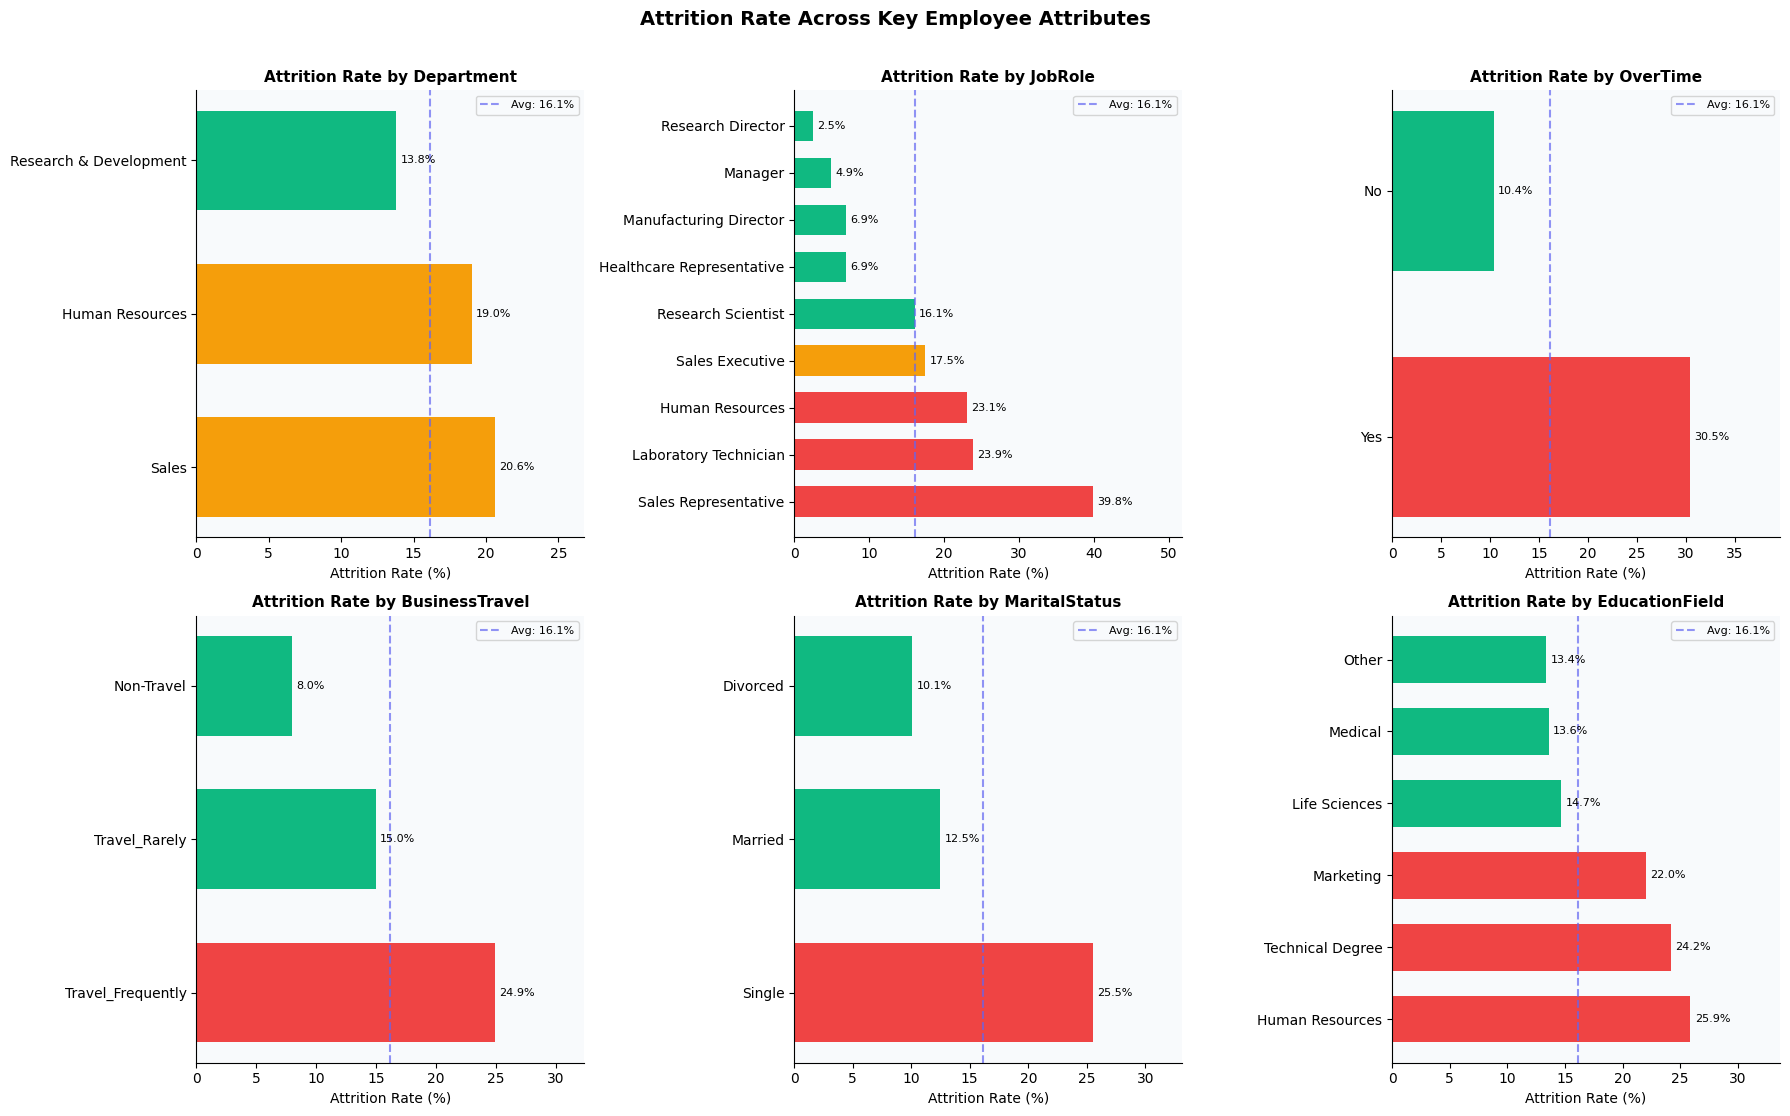

In [10]:
# Attrition rate by key categorical features
cat_features = ['Department', 'JobRole', 'OverTime',
                'BusinessTravel', 'MaritalStatus', 'EducationField']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor('white')
axes = axes.flatten()

overall_rate = df['Attrition_Binary'].mean() * 100

for ax, col in zip(axes, cat_features):
    rates = (
        df.groupby(col)['Attrition_Binary']
          .mean().mul(100).round(1)
          .sort_values(ascending=False)
          .reset_index()
    )
    bar_colors = [
        C['attrition'] if v >= overall_rate * 1.3
        else C['mid_risk'] if v >= overall_rate
        else C['retained']
        for v in rates['Attrition_Binary']
    ]
    bars = ax.barh(
        rates[col].astype(str),
        rates['Attrition_Binary'],
        color=bar_colors, edgecolor='none', height=0.65
    )
    ax.axvline(overall_rate, color=C['primary'], linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'Avg: {overall_rate:.1f}%')
    ax.set_title(f'Attrition Rate by {col}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Attrition Rate (%)')
    ax.set_facecolor(C['bg'])
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
    ax.set_xlim(0, rates['Attrition_Binary'].max() * 1.3)
    ax.legend(fontsize=8)

plt.suptitle('Attrition Rate Across Key Employee Attributes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/attrition_by_feature.png', dpi=120, bbox_inches='tight')
plt.show()


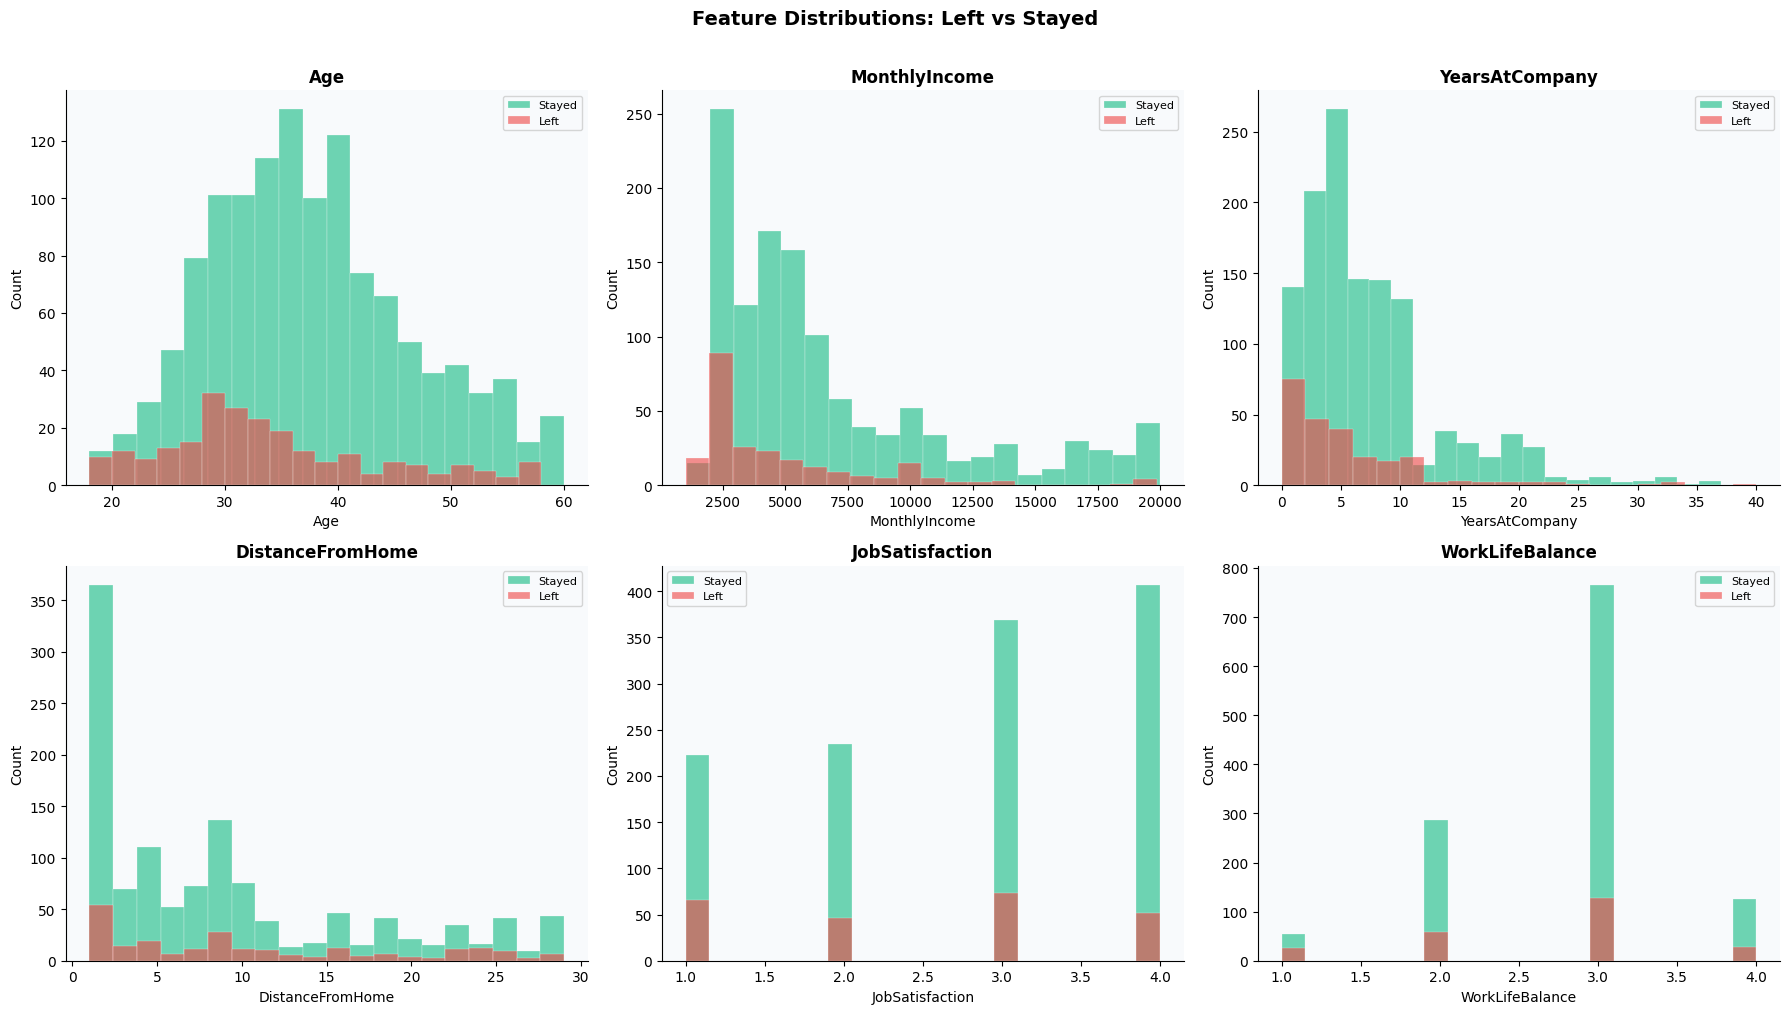

In [11]:
# Numeric feature distributions: left vs stayed
num_features = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    for label, color in [('No', C['retained']), ('Yes', C['attrition'])]:
        subset = df[df['Attrition'] == label][col]
        ax.hist(subset, bins=20, alpha=0.6, color=color,
                label=f'{"Left" if label=="Yes" else "Stayed"}',
                edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.set_facecolor(C['bg'])

plt.suptitle('Feature Distributions: Left vs Stayed',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 6: Financial Cost of Attrition

We estimate the cost of each attrition event using industry benchmarks:

- **Entry level positions:** 50% of annual salary
- **Mid-level positions:** 100% of annual salary
- **Senior positions:** 150% of annual salary

Seniority is estimated from JobLevel (1-5 scale in the dataset).


In [12]:
def attrition_cost_multiplier(job_level):
    if job_level <= 1:   return 0.50
    elif job_level <= 3: return 1.00
    else:                return 1.50

df['annual_income']      = df['MonthlyIncome'] * 12
df['cost_multiplier']    = df['JobLevel'].apply(attrition_cost_multiplier)
df['attrition_cost_usd'] = df['annual_income'] * df['cost_multiplier']

# Cost only applies to employees who left
left_df = df[df['Attrition'] == 'Yes'].copy()

dept_cost = (
    left_df.groupby('Department')
           .agg(
               attritions    = ('Attrition_Binary', 'count'),
               total_cost    = ('attrition_cost_usd', 'sum'),
               avg_cost      = ('attrition_cost_usd', 'mean'),
           )
           .reset_index()
           .sort_values('total_cost', ascending=False)
)

print('Financial Cost of Attrition by Department:')
print(dept_cost.to_string(index=False))
print()
print(f'Total estimated attrition cost: USD {left_df["attrition_cost_usd"].sum():,.0f}')
print(f'Avg cost per attrition event:   USD {left_df["attrition_cost_usd"].mean():,.0f}')


Financial Cost of Attrition by Department:
            Department  attritions  total_cost     avg_cost
                 Sales          92   6620748.0 71964.652174
Research & Development         133   5352852.0 40247.007519
       Human Resources          12    390126.0 32510.500000

Total estimated attrition cost: USD 12,363,726
Avg cost per attrition event:   USD 52,168


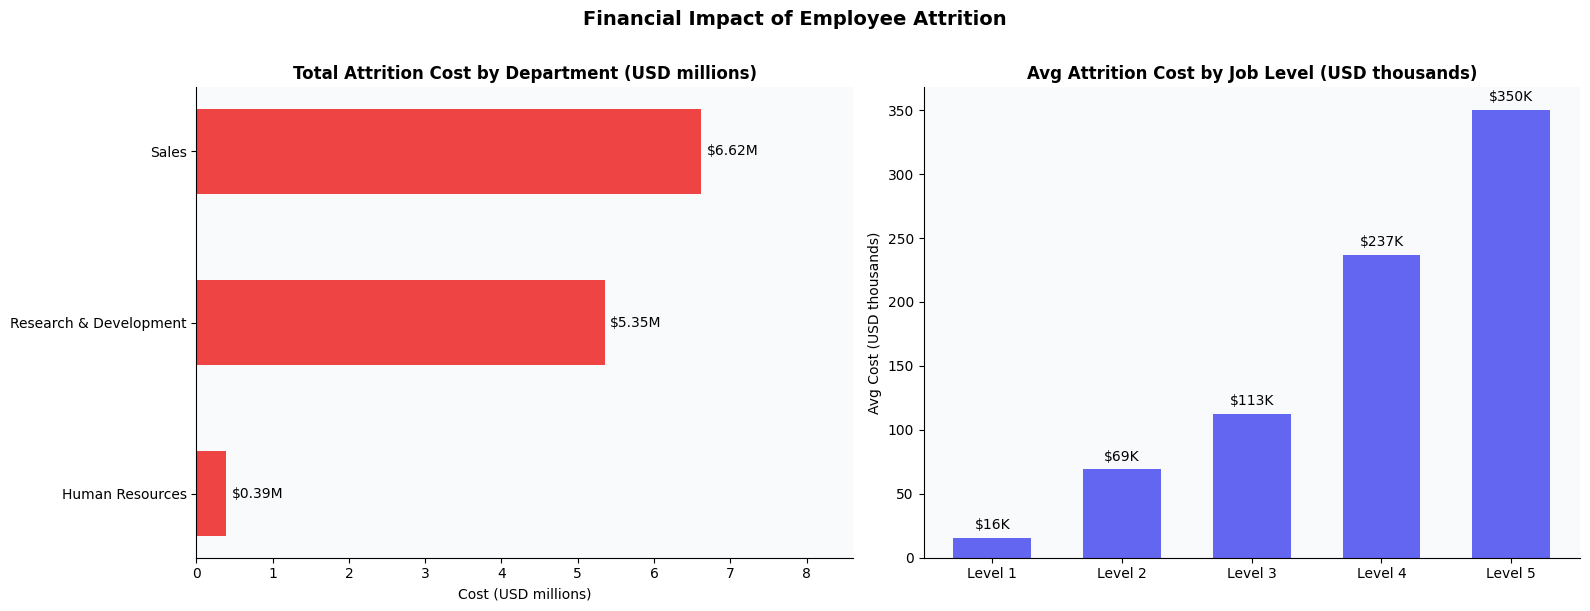

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Cost by department
bars1 = axes[0].barh(
    dept_cost['Department'],
    dept_cost['total_cost'] / 1e6,
    color=C['attrition'], edgecolor='none', height=0.5
)
axes[0].set_title('Total Attrition Cost by Department (USD millions)',
                  fontweight='bold')
axes[0].set_xlabel('Cost (USD millions)')
axes[0].invert_yaxis()
axes[0].set_facecolor(C['bg'])
axes[0].bar_label(
    bars1,
    labels=[f'${v/1e6:.2f}M' for v in dept_cost['total_cost']],
    padding=4, fontsize=10
)
axes[0].set_xlim(0, dept_cost['total_cost'].max() / 1e6 * 1.3)

# Avg cost by job level
jl_cost = (
    left_df.groupby('JobLevel')['attrition_cost_usd']
           .mean()
           .reset_index()
)
bars2 = axes[1].bar(
    [f'Level {l}' for l in jl_cost['JobLevel']],
    jl_cost['attrition_cost_usd'] / 1000,
    color=C['primary'], edgecolor='none', width=0.6
)
axes[1].set_title('Avg Attrition Cost by Job Level (USD thousands)',
                  fontweight='bold')
axes[1].set_ylabel('Avg Cost (USD thousands)')
axes[1].set_facecolor(C['bg'])
axes[1].bar_label(
    bars2,
    labels=[f'${v/1000:.0f}K' for v in jl_cost['attrition_cost_usd']],
    padding=4, fontsize=10
)

plt.suptitle('Financial Impact of Employee Attrition',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/attrition_cost.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 7: Attrition Prediction Model

In [14]:
# Encode all categoricals
df_model = df.copy()
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns
cat_cols = [c for c in cat_cols if c != 'Attrition']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

feature_cols = [c for c in df_model.columns
                if c not in ['Attrition', 'Attrition_Binary',
                             'annual_income', 'cost_multiplier', 'attrition_cost_usd']]

X = df_model[feature_cols]
y = df_model['Attrition_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=200, random_state=42,
    class_weight='balanced', n_jobs=-1
)
rf.fit(X_train_s, y_train)

y_prob = rf.predict_proba(X_test_s)[:, 1]
y_pred = rf.predict(X_test_s)
auc    = roc_auc_score(y_test, y_prob)

print(f'Random Forest ROC-AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Left']))


Random Forest ROC-AUC: 0.7796

              precision    recall  f1-score   support

    Retained       0.85      0.98      0.91       247
        Left       0.43      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.64      0.52      0.51       294
weighted avg       0.78      0.84      0.78       294



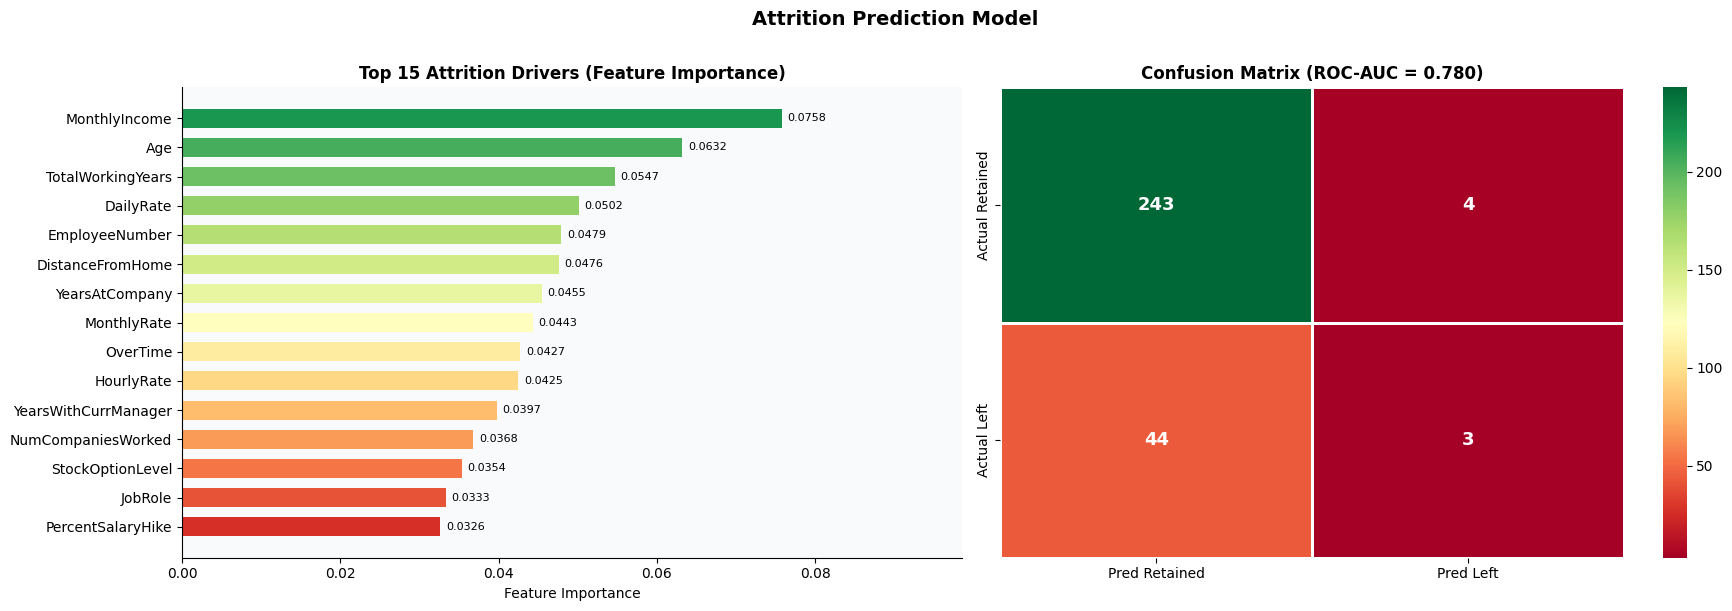

In [15]:
# Feature importance
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')

# Feature importance
import matplotlib.cm as cm
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importance_df)))
bars = axes[0].barh(
    importance_df['feature'], importance_df['importance'],
    color=colors, edgecolor='none', height=0.65
)
axes[0].set_title('Top 15 Attrition Drivers (Feature Importance)',
                  fontweight='bold')
axes[0].set_xlabel('Feature Importance')
axes[0].invert_yaxis()
axes[0].set_facecolor(C['bg'])
axes[0].bar_label(bars, fmt='%.4f', padding=4, fontsize=8)
axes[0].set_xlim(0, importance_df['importance'].max() * 1.3)

# Confusion matrix
cm_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm_mat, annot=True, fmt='d', cmap='RdYlGn',
    xticklabels=['Pred Retained', 'Pred Left'],
    yticklabels=['Actual Retained', 'Actual Left'],
    ax=axes[1], linewidths=1, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'}
)
axes[1].set_title(f'Confusion Matrix (ROC-AUC = {auc:.3f})',
                  fontweight='bold')

plt.suptitle('Attrition Prediction Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/model_results.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 8: The Finding Most Analyses Miss

### Employee Risk Matrix: Risk Score vs Seniority

Most attrition analyses report which groups are at risk. This section goes further by assigning an individual risk score to every current employee and plotting them on a Risk Matrix.

The two dimensions are:

- **Attrition Risk Score:** model-predicted probability of leaving (0 to 100)
- **Seniority:** job level (1 to 5)

The most critical quadrant is **High Risk + High Seniority**: senior employees with high attrition probability. These are the most expensive to replace and the most damaging to lose.

A second critical quadrant is **High Risk + Low Seniority**: early-tenure employees likely to leave before the business recoups its hiring investment.


In [19]:
# Score all current employees
X_all   = df_model[feature_cols]
X_all_s = scaler.transform(X_all)
df['risk_score'] = rf.predict_proba(X_all_s)[:, 1] * 100

# Classify risk tier
df['risk_tier'] = df['risk_score'].apply(
    lambda x: 'High Risk' if x >= 60
    else ('Mid Risk' if x >= 30
    else 'Low Risk')
)

# Risk matrix scatter
risk_colors = {
    'High Risk': C['high_risk'],
    'Mid Risk':  C['mid_risk'],
    'Low Risk':  C['low_risk'],
}

fig = px.scatter(
    df,
    x='JobLevel',
    y='risk_score',
    color='risk_tier',
    color_discrete_map=risk_colors,
    size='MonthlyIncome',
    hover_data={
        'JobRole':          True,
        'Department':       True,
        'YearsAtCompany':   True,
        'MonthlyIncome':    ':,',
        'risk_score':       ':.1f',
        'Attrition':        True,
        'risk_tier':        False,
    },
    title='Employee Risk Matrix: Attrition Risk Score vs Job Level',
    labels={
        'JobLevel':   'Job Level (Seniority)',
        'risk_score': 'Attrition Risk Score (0-100)',
        'risk_tier':  'Risk Tier',
    },
    opacity=0.65,
)
fig.add_hline(
    y=60, line_dash='dash', line_color=C['high_risk'],
    line_width=1.5, annotation_text='High risk threshold',
    annotation_font_size=9
)
fig.add_hline(
    y=30, line_dash='dash', line_color=C['mid_risk'],
    line_width=1.5, annotation_text='Mid risk threshold',
    annotation_font_size=9
)
fig.update_layout(
    height=540,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
    legend_title_text='Risk Tier',
    xaxis=dict(tickmode='array', tickvals=[1,2,3,4,5],
               ticktext=['L1','L2','L3','L4','L5']),
)
fig.show()

high_risk_df   = df[df['risk_tier'] == 'High Risk']
critical_df    = df[(df['risk_tier'] == 'High Risk') & (df['JobLevel'] >= 4)]
total_risk_cost = high_risk_df['attrition_cost_usd'].sum()

print(f'Total high-risk employees:             {len(high_risk_df):,}')
print(f'Critical (high risk + senior, L4/L5): {len(critical_df):,}')
print(f'Potential cost if all high-risk leave: USD {total_risk_cost:,.0f}')


Total high-risk employees:             194
Critical (high risk + senior, L4/L5): 9
Potential cost if all high-risk leave: USD 10,230,924


In [17]:
# Risk tier summary
risk_summary = df.groupby('risk_tier').agg(
    employees        = ('Attrition_Binary', 'count'),
    actual_attrition = ('Attrition_Binary', 'sum'),
    avg_risk_score   = ('risk_score',       'mean'),
    avg_income       = ('MonthlyIncome',    'mean'),
    avg_tenure       = ('YearsAtCompany',   'mean'),
).round(1)
risk_summary['attrition_rate_%'] = (
    risk_summary['actual_attrition'] / risk_summary['employees'] * 100
).round(1)

print('Risk Tier Summary:')
print(risk_summary.to_string())

# Top 10 highest risk employees
print()
print('Top 10 Highest Risk Employees (anonymised):')
top_risk = df.nlargest(10, 'risk_score')[
    ['Department', 'JobRole', 'JobLevel', 'YearsAtCompany',
     'MonthlyIncome', 'risk_score', 'Attrition']
].round(1)
print(top_risk.to_string(index=False))


Risk Tier Summary:
           employees  actual_attrition  avg_risk_score  avg_income  avg_tenure  attrition_rate_%
risk_tier                                                                                       
High Risk        194               193            74.0      4779.3         4.8              99.5
Low Risk        1239                28             6.2      6877.6         7.5               2.3
Mid Risk          37                16            39.1      2995.8         2.3              43.2

Top 10 Highest Risk Employees (anonymised):
            Department               JobRole  JobLevel  YearsAtCompany  MonthlyIncome  risk_score Attrition
Research & Development Laboratory Technician         1               1           2340        94.0       Yes
Research & Development    Research Scientist         1               1           2439        93.0       Yes
                 Sales  Sales Representative         1               0           1878        90.5       Yes
Research & Developm

---
## Section 9: Executive Summary Dashboard

In [20]:
total_employees  = len(df)
overall_attr     = df['Attrition_Binary'].mean() * 100
high_risk_count  = len(df[df['risk_tier'] == 'High Risk'])
critical_count   = len(critical_df)
total_cost_est   = left_df['attrition_cost_usd'].sum()
top_dept_risk    = dept_df.iloc[0]['Department']

kpis = [
    ('Total Employees',       f'{total_employees:,}',         'in dataset',                        C['primary']),
    ('Overall Attrition Rate',f'{overall_attr:.1f}%',         'employees who left',                C['attrition']),
    ('Model ROC-AUC',         f'{auc:.3f}',                   'attrition prediction power',        C['primary']),
    ('High Risk Employees',   f'{high_risk_count:,}',         'risk score >= 60',                  C['mid_risk']),
    ('Critical Risk (Senior)',f'{critical_count}',            'high risk + L4/L5',                 C['attrition']),
    ('Est. Attrition Cost',   f'USD {total_cost_est/1e6:.1f}M','total replacement cost incurred',  C['attrition']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='HR Analytics | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)
for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx, cy = col + 0.5, row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=17, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')
fig.show()


---
## Section 10: Findings and Recommendations

### Key Findings

| Finding | Evidence |
|---------|----------|
| Attrition rate varies significantly across departments and roles | SQL department analysis |
| Overtime is strongly associated with higher attrition | SQL overtime query |
| Monthly income, overtime, and years at company are top attrition drivers | Feature importance chart |
| A distinct high-risk employee population is identifiable before they resign | Risk matrix |
| The financial cost of attrition is concentrated in specific departments | Cost analysis |

---

### Recommendations

**1. Address Overtime as an Urgent Attrition Driver**

The data consistently shows overtime as one of the strongest predictors of attrition. Employees working overtime are significantly more likely to leave. Before increasing workload, HR and management should model the expected attrition cost of sustained overtime against the cost of hiring additional capacity.

**2. Prioritise Retention Investment on Critical Risk Employees**

The Risk Matrix identifies employees who are both high-risk and senior. These individuals represent the highest replacement cost and the greatest institutional knowledge loss. Targeted retention interventions, salary reviews, and direct manager conversations should begin before these employees reach the resignation stage.

**3. Conduct Stay Interviews with High-Risk Employees**

Rather than waiting for exit interviews after employees have already decided to leave, use the risk scores to conduct proactive stay interviews. Ask high-risk employees what would make them stay. The data tells you who to talk to. The conversation tells you what to do.

**4. Review Compensation in High-Attrition Roles**

Income is a top attrition driver in the feature importance analysis. Roles with above-average attrition rates should be benchmarked against market salaries. In many cases, a proactive salary adjustment costs less than the replacement cost of losing the employee.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
